# Make figures demonstrating UAT


In [3]:
import matplotlib.pyplot as plt
import scipy
import numpy as np

In [46]:
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.dpi'] = 300 


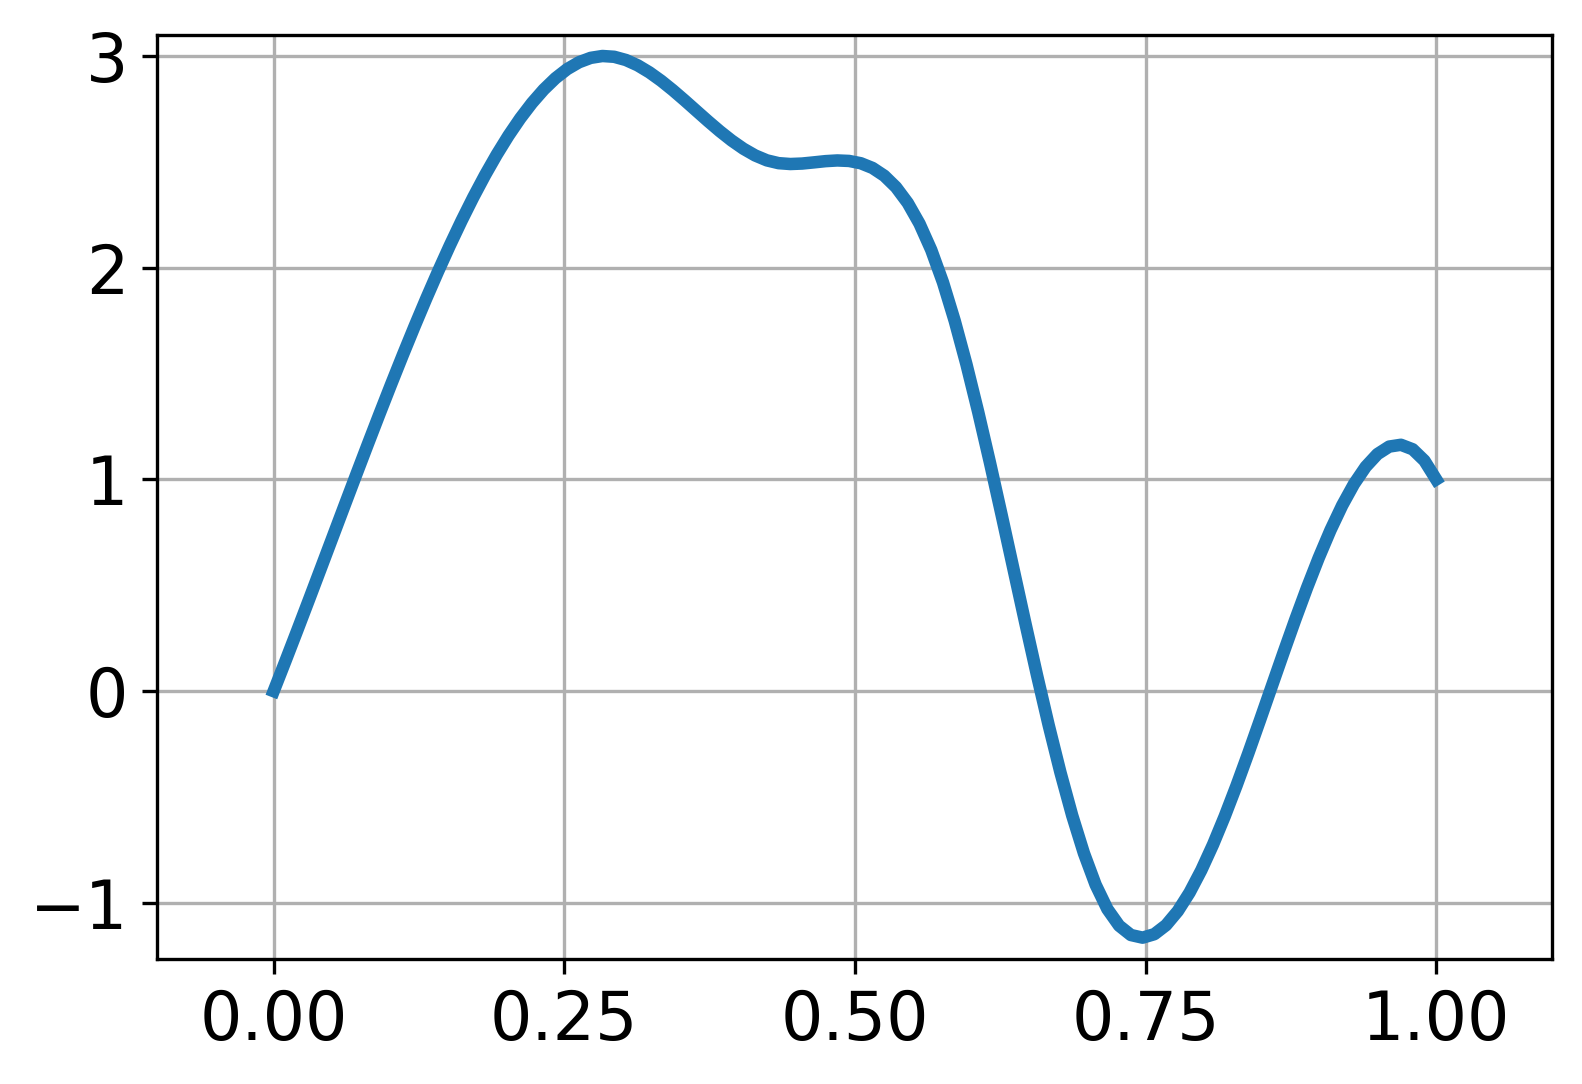

In [150]:
# Generate some arbitrary function 
# Method: spline with a few points
x0 = np.linspace(0., 1., 8)
y0 = np.array([0., 2., 3., 2.5, 2., -1., 0., 1.])
f = scipy.interpolate.CubicSpline(x0, y0)

xx = np.linspace(0., 1., 100)
yy = f(xx)

fig, ax = plt.subplots()
ax.plot(xx, yy)
xlim = (np.min(xx) - 0.1, np.max(xx) + 0.1)
ylim = (np.min(yy) - 0.1, np.max(yy) + 0.1)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
fig.savefig("uat_none.svg")

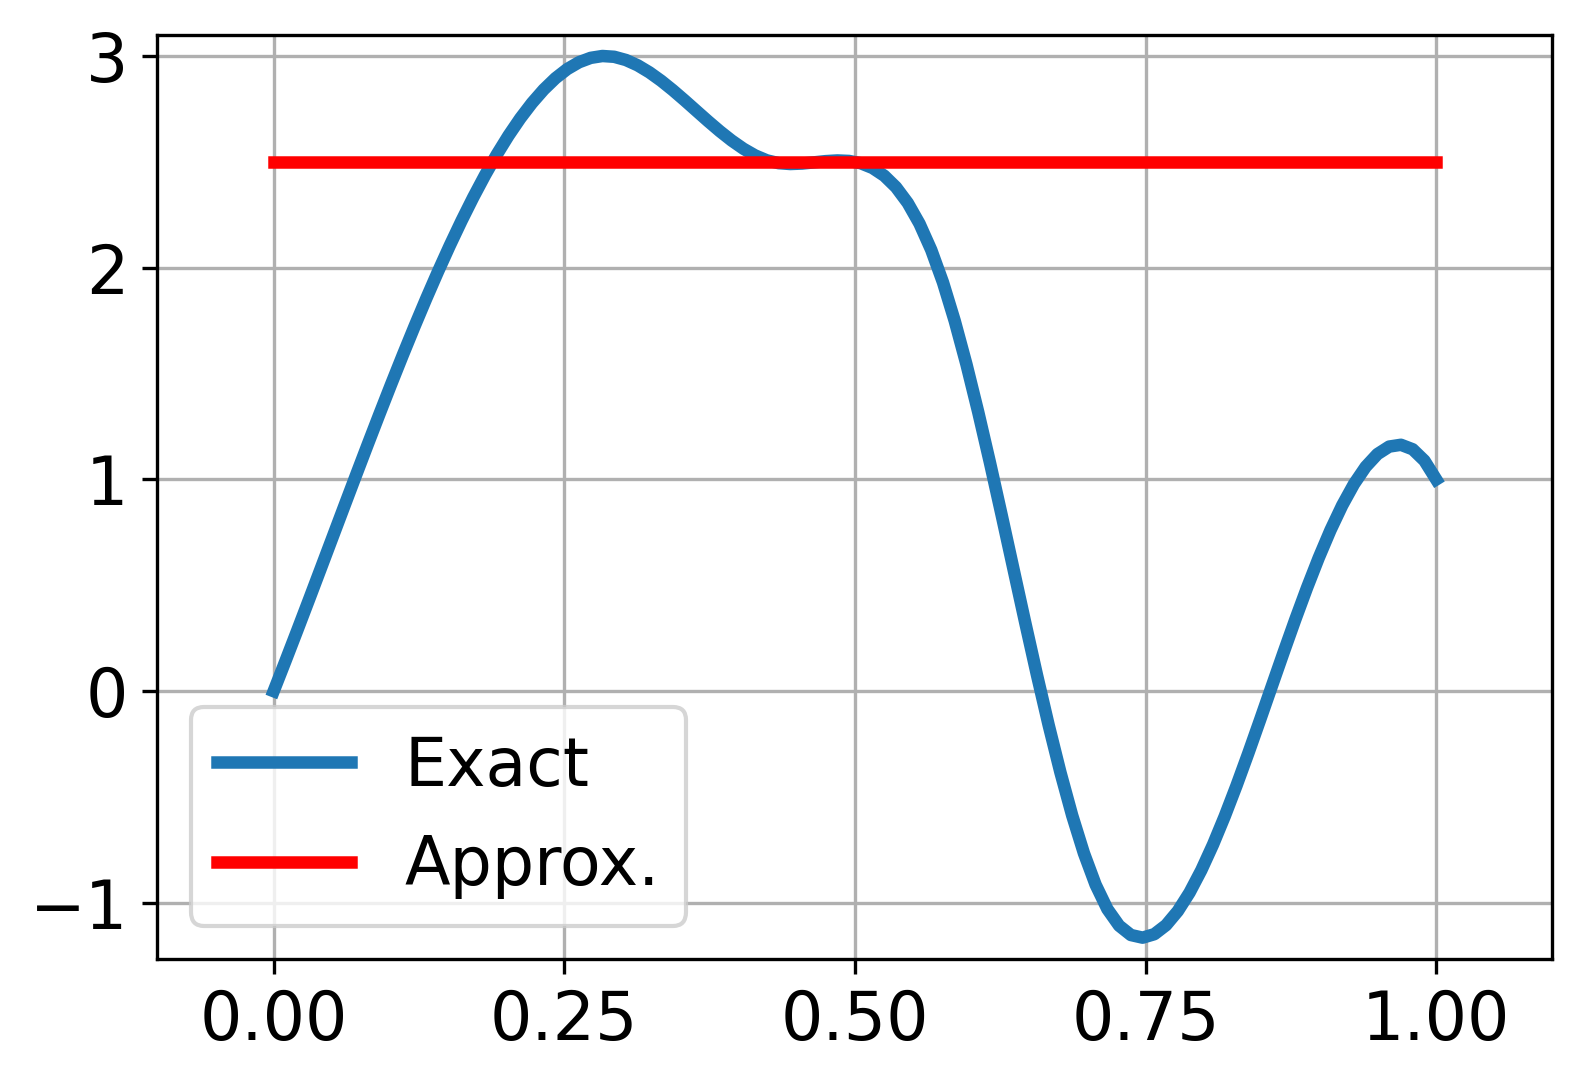

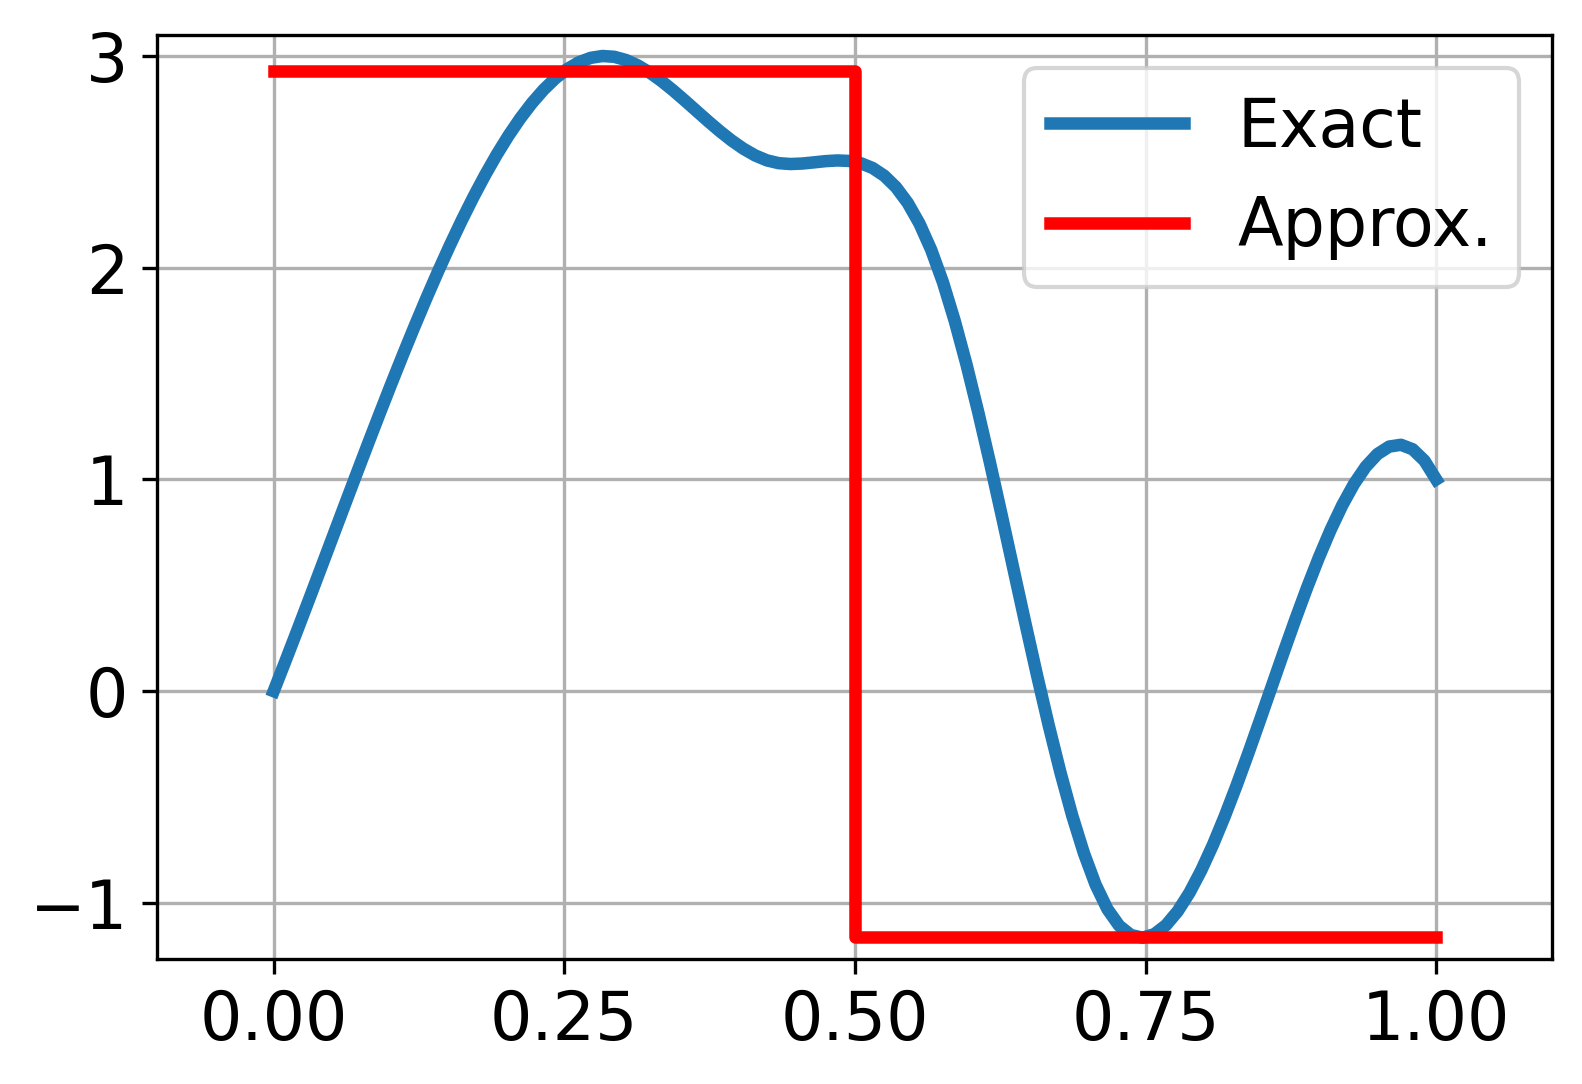

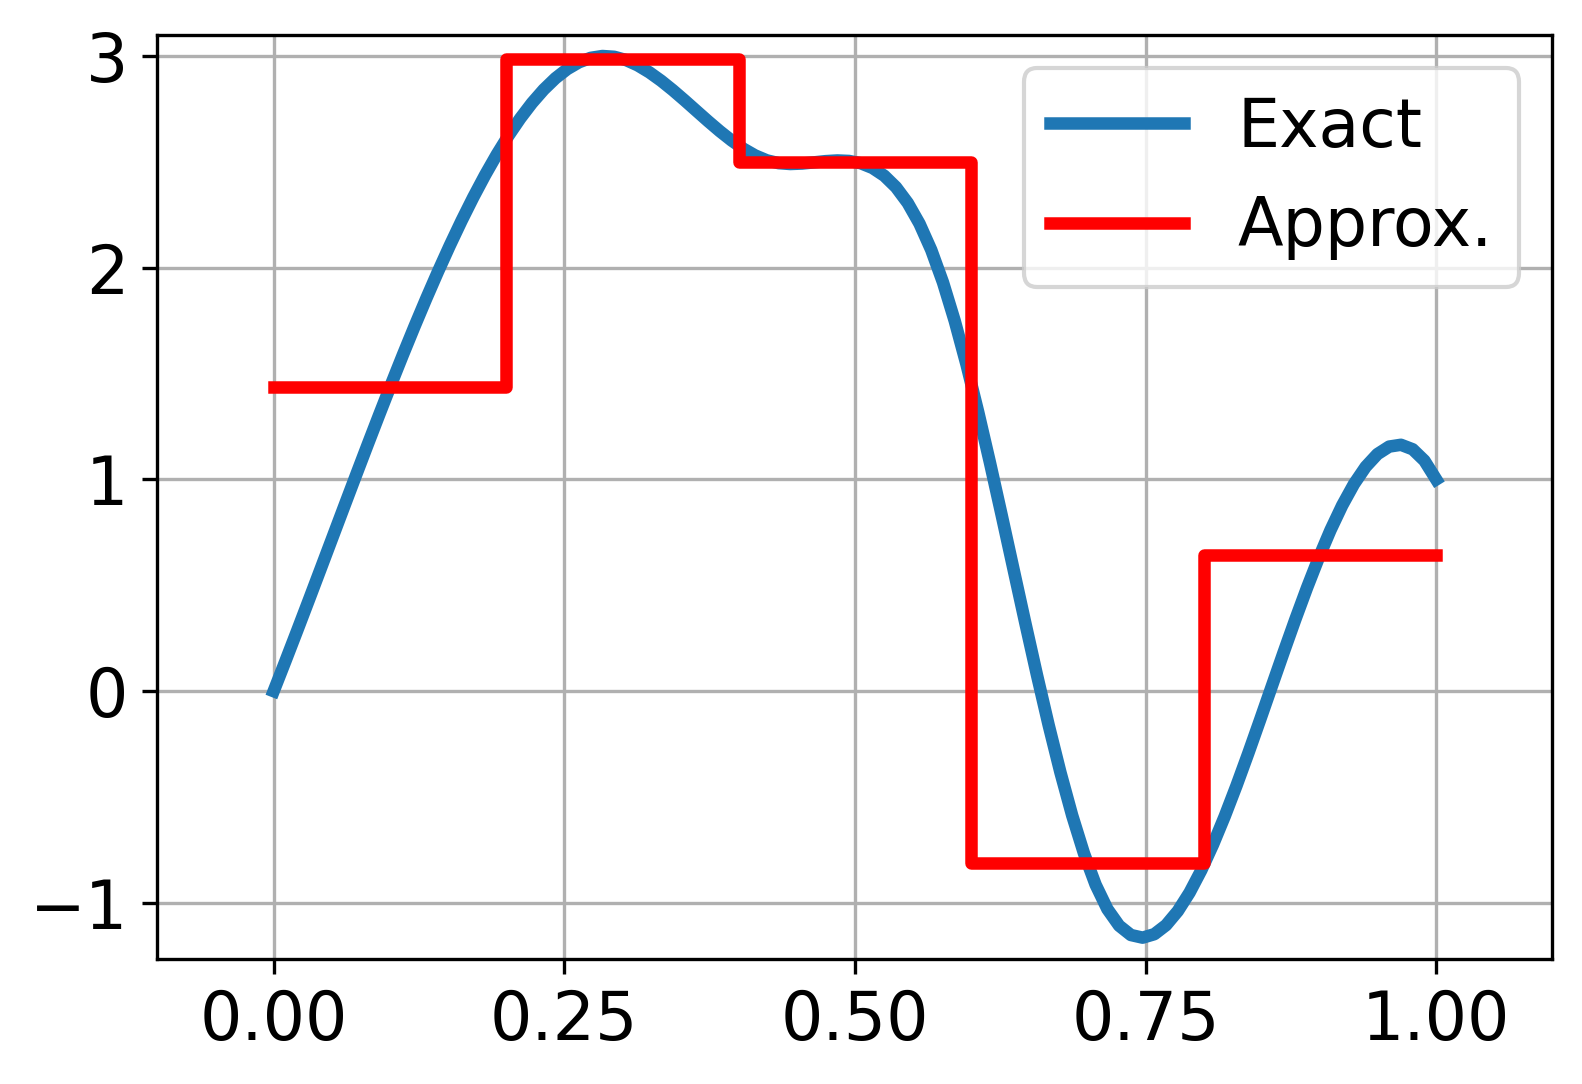

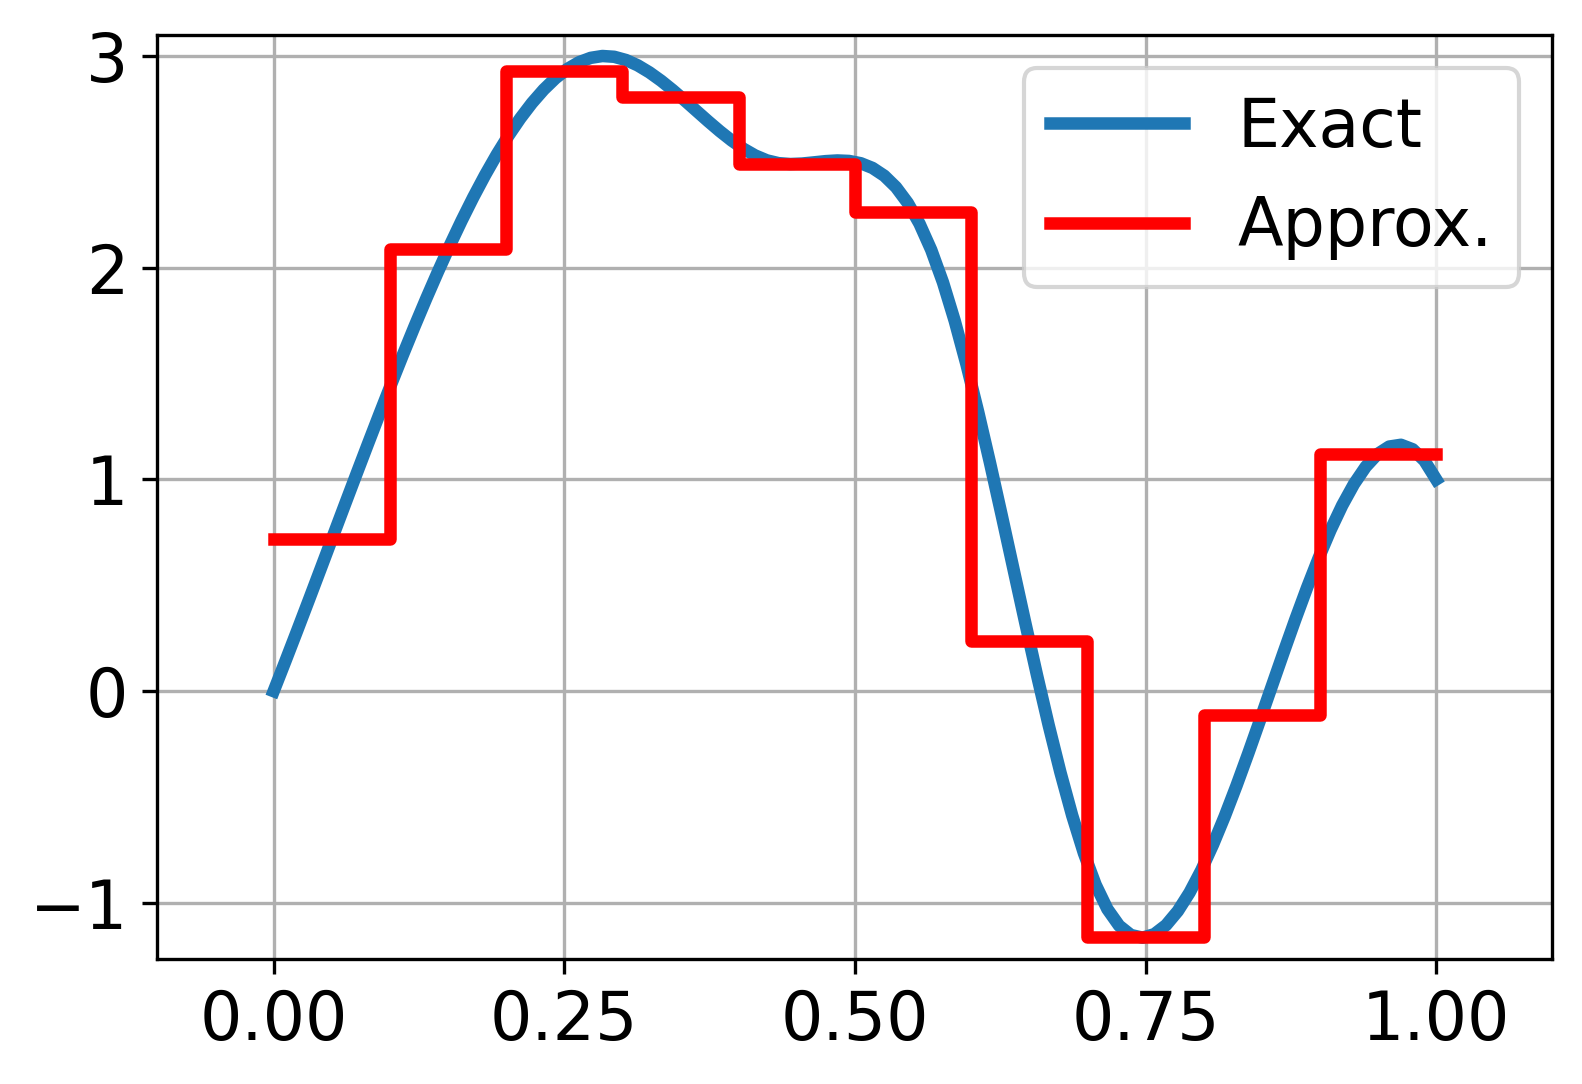

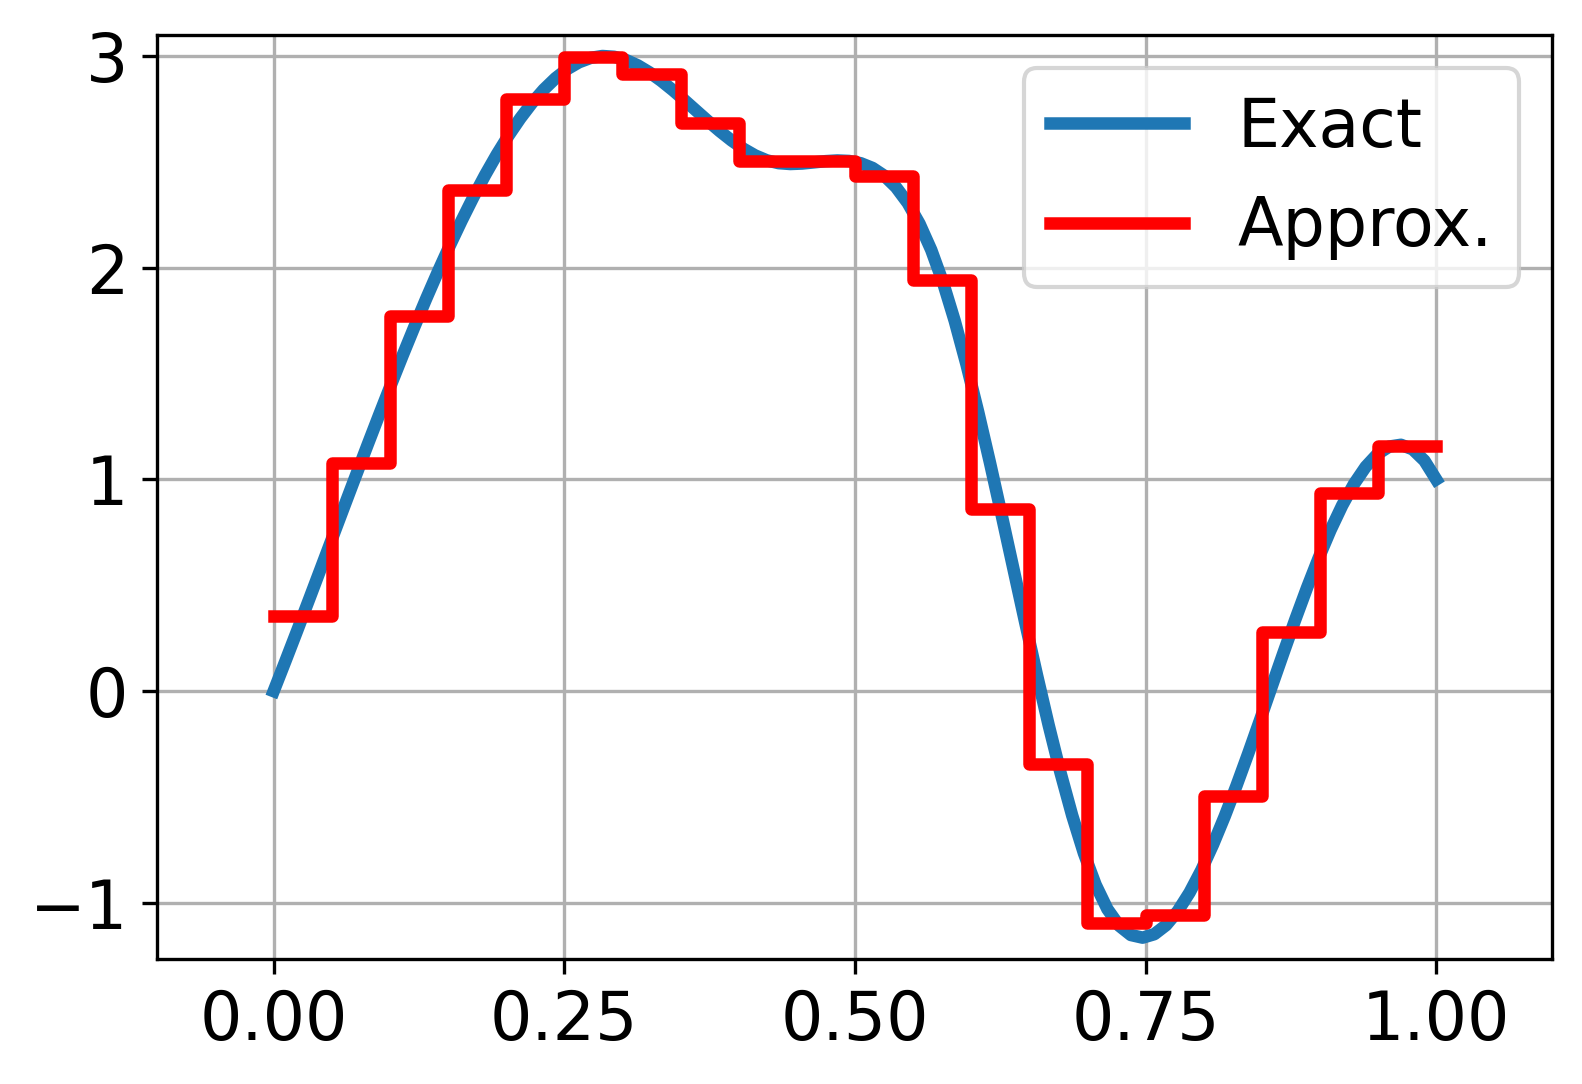

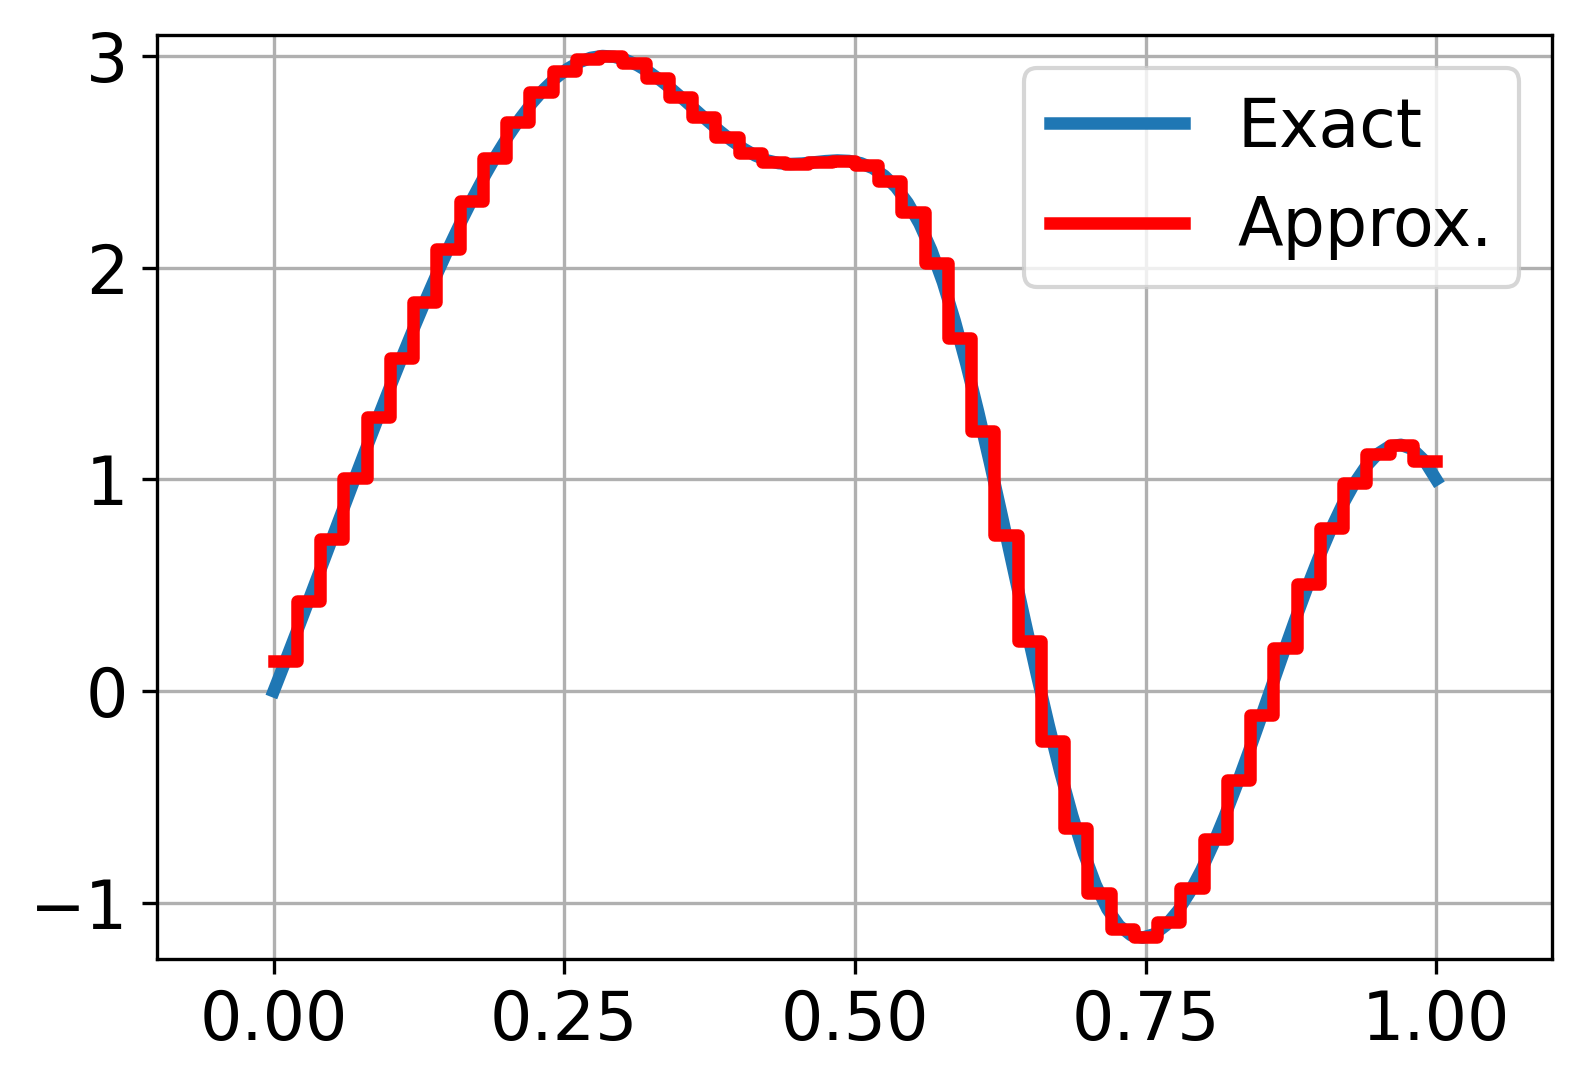

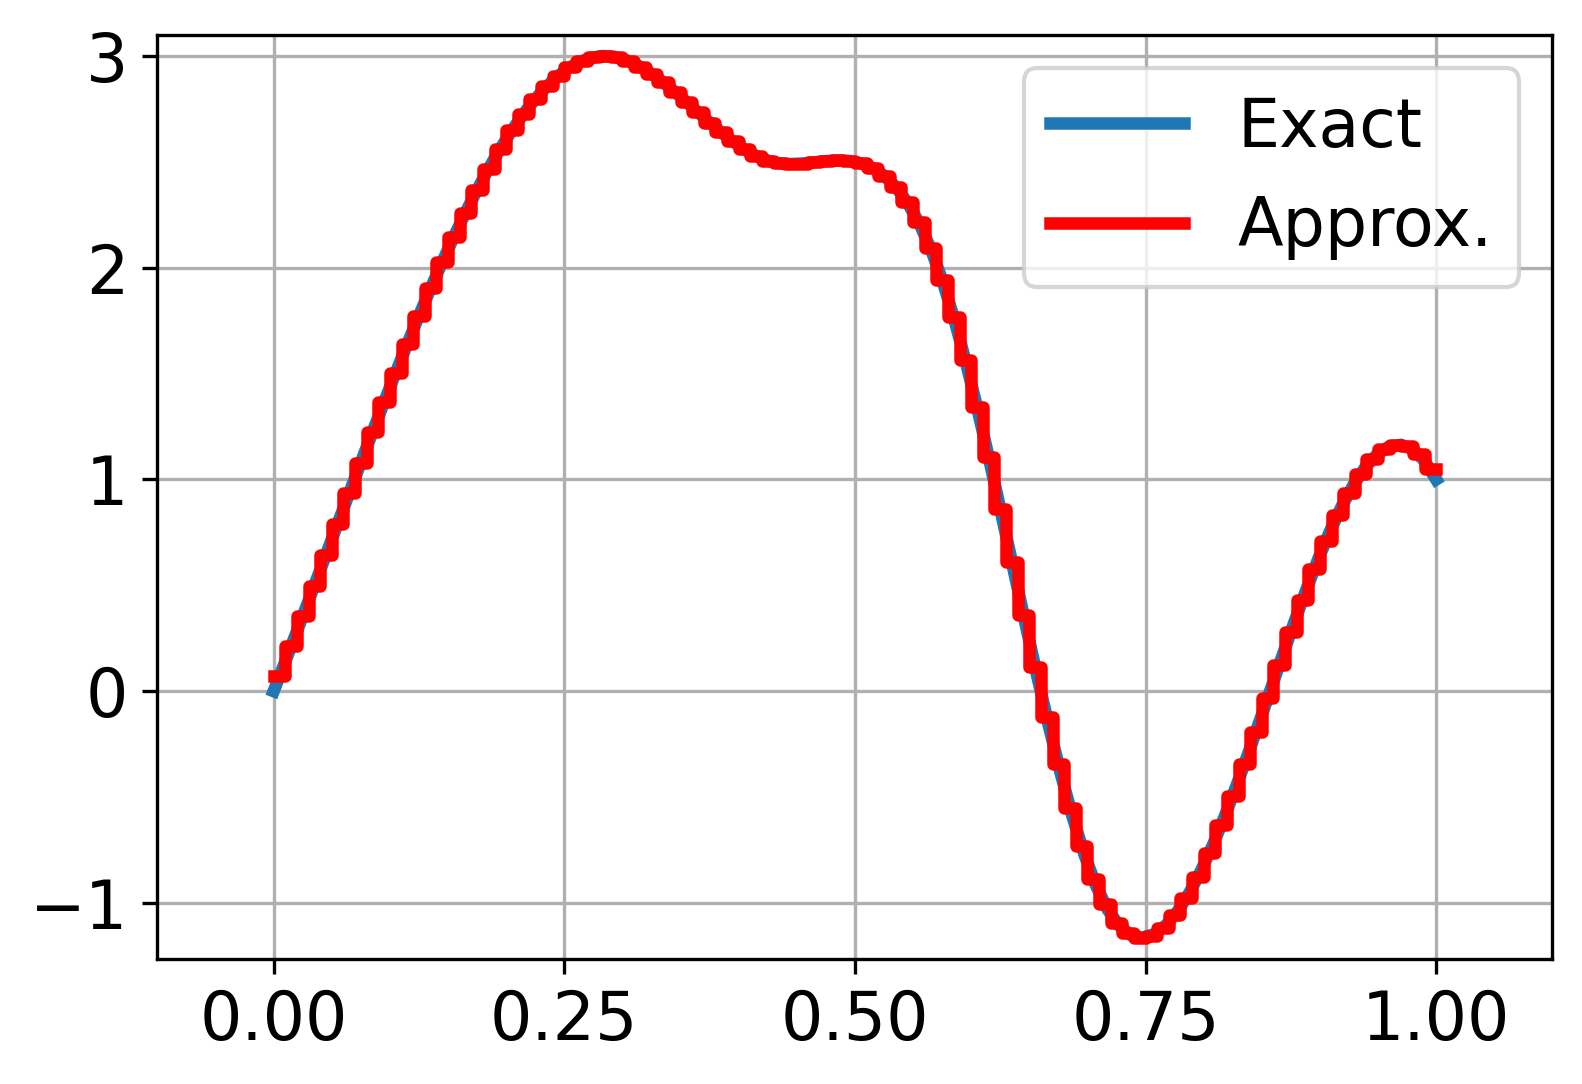

In [147]:
def step_approx(f, x):
    '''
    Create a step function approximation to f defined at a set of points x
    '''
    xx = np.zeros(len(x)*2 - 2) # [x[0], x[1], x[1], x[2], x[2], x[3], x[3], ..., x[n-2], x[n-2], x[n-1]]
    yy = np.zeros(len(x)*2 - 2) # [f((x[0]+x[1])/2), same, f((x[1]+x[2])/2), same, ..., f((x[n-3]+x[n-2])/2), f((x[n-2]+x[n-1])/2), same)
    xx[:-1:2] = x[:-1] # even index = left endpoints
    xx[1::2] = x[1:] # odd index = right endpoints
    yy[:-1:2] = f((x[:-1] + x[1:])/2)
    yy[1::2] = yy[:-1:2] # Right y-coordinate == left y-coordinate
    return xx, yy

for npt in [1, 2, 5, 10, 20, 50, 100]:
    xx_approx, yy_approx = step_approx(f, np.linspace(0., 1., npt+1))
    fig, ax = plt.subplots()
    ax.plot(xx, yy, label="Exact")
    ax.plot(xx_approx, yy_approx, color="red", label="Approx.")
    ax.legend()
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    fig.savefig(f"uat_{npt}.svg")

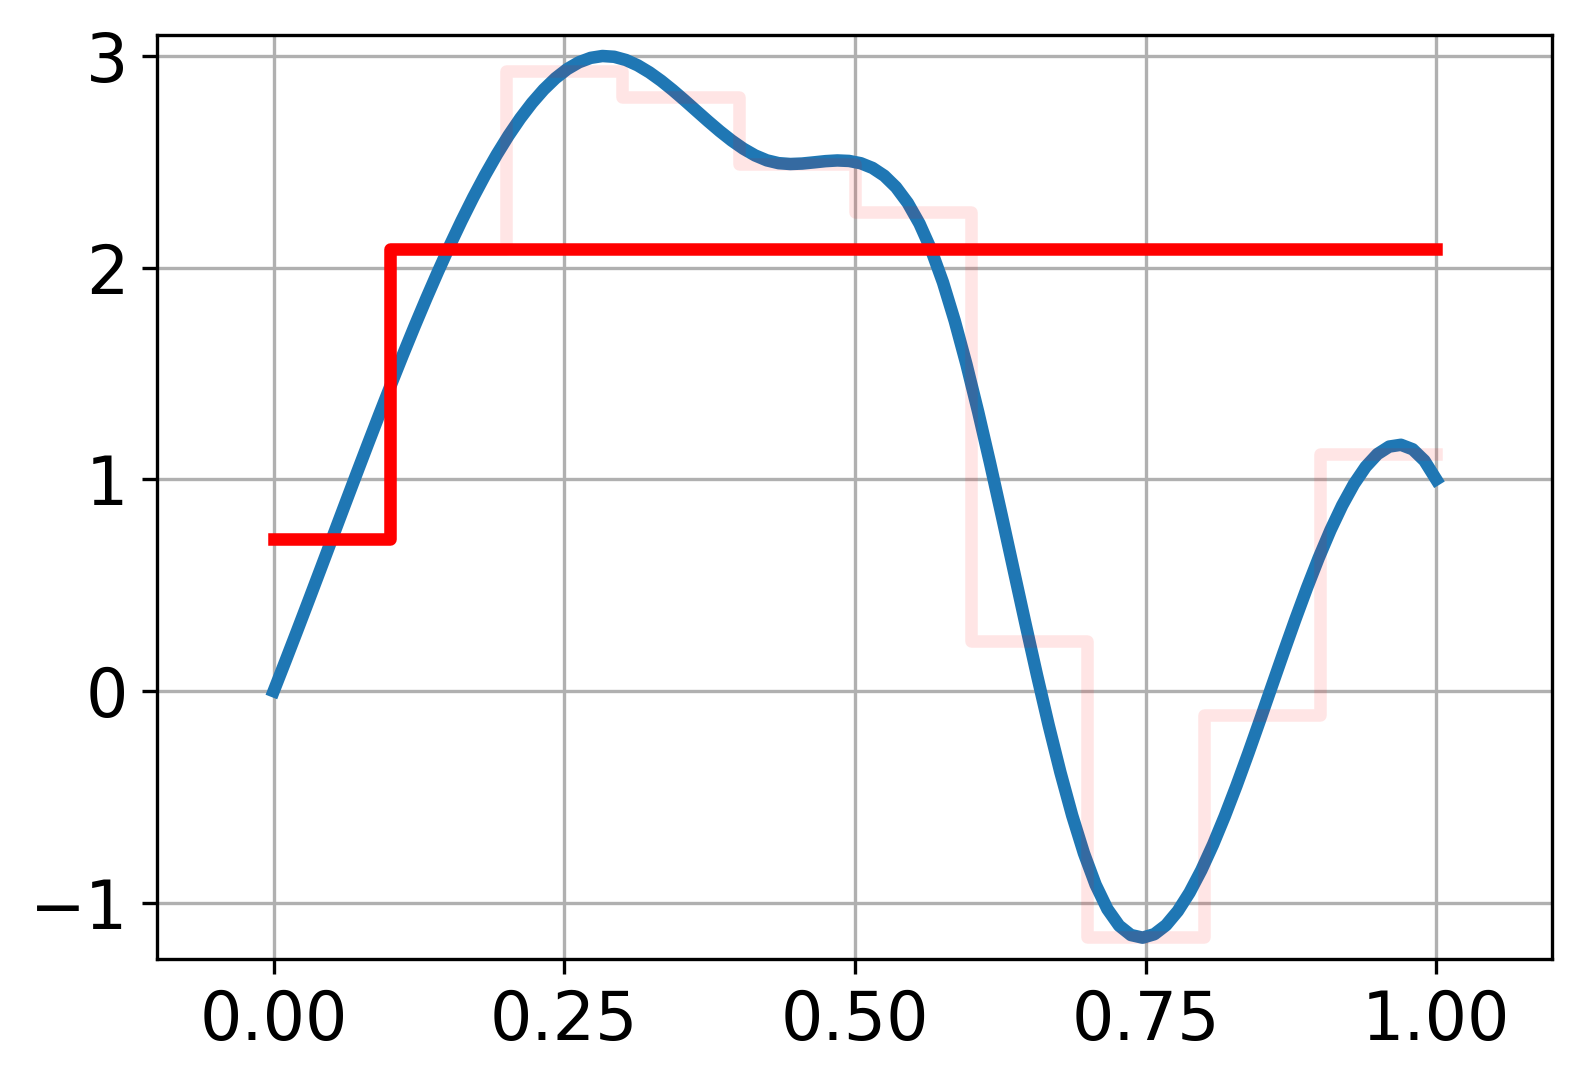

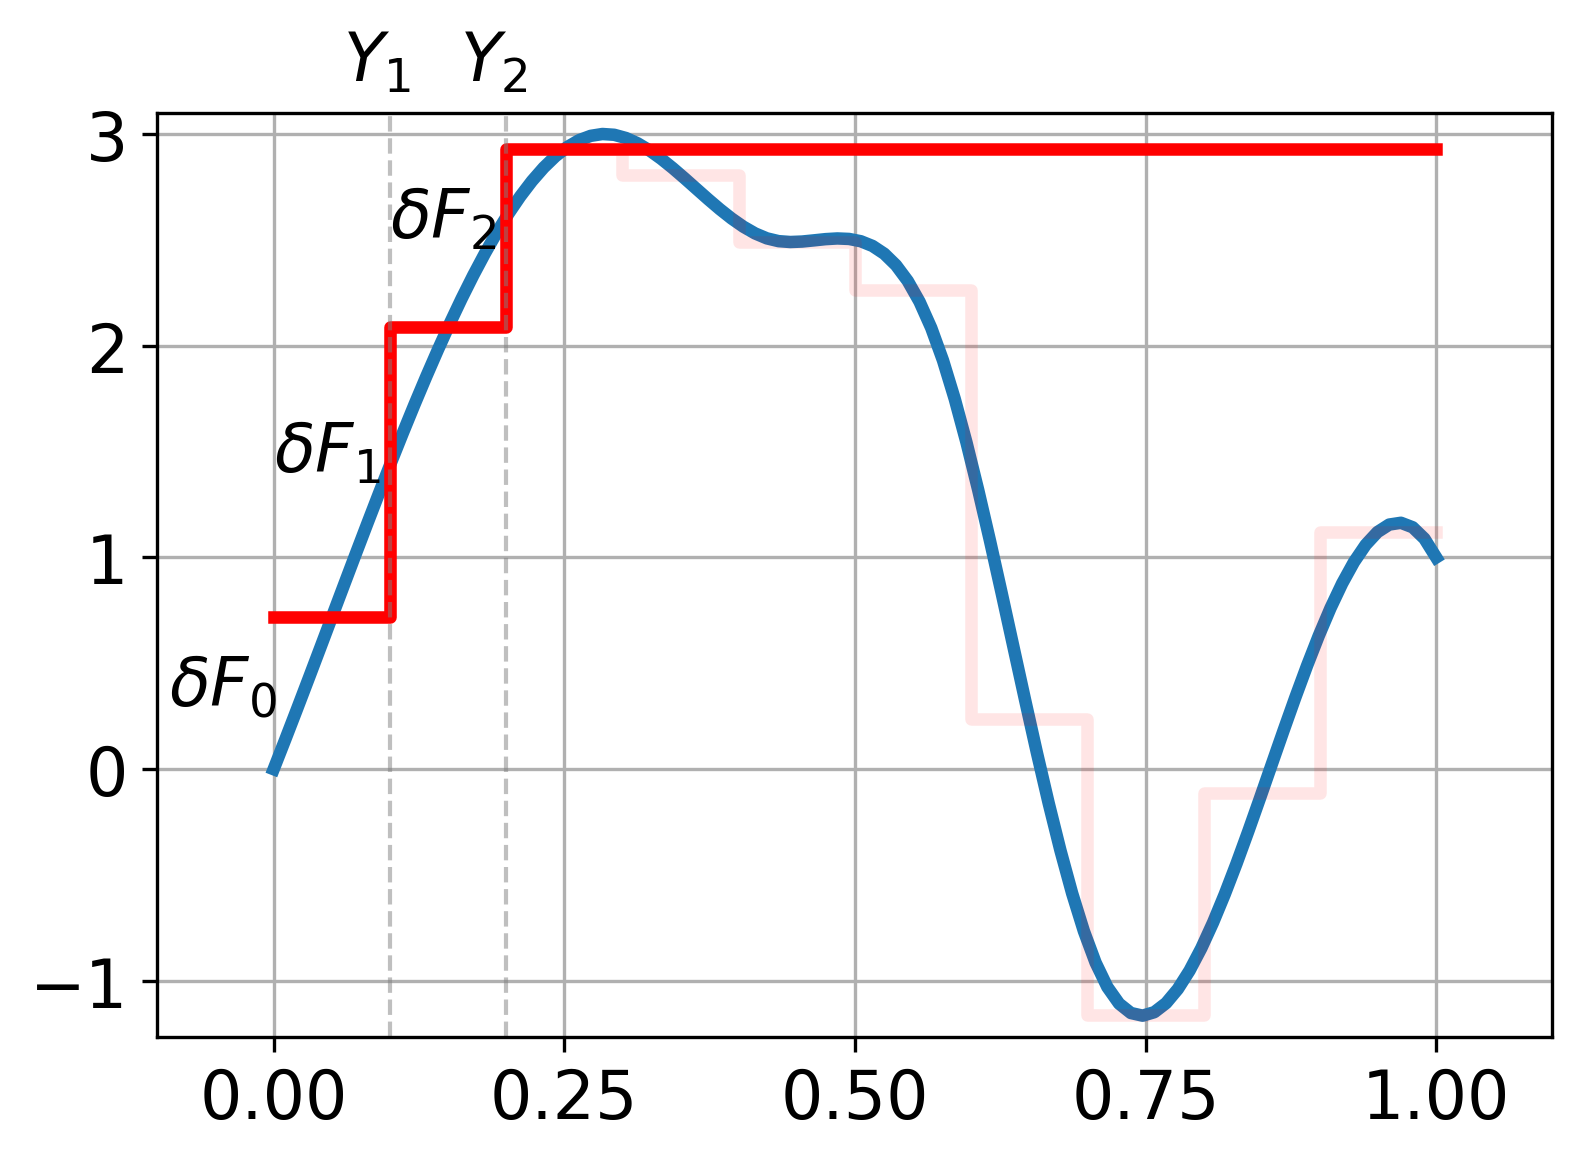

In [157]:
# Visualize building a UAT
npt = 10
xx_approx, yy_approx = step_approx(f, np.linspace(0., 1., npt+1))

# One step 
fig, ax = plt.subplots()
ax.plot(xx, yy)
ax.plot(xx_approx, yy_approx, color="red", alpha=0.1)

xx_step1 = np.array([xx_approx[0], xx_approx[1], xx_approx[1], xx_approx[-1]])
yy_step1 = np.array([yy_approx[0], yy_approx[1], yy_approx[2], yy_approx[2]])
ax.plot(xx_step1, yy_step1, color="red")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
fig.savefig("uat_build_1.svg")

# Two steps
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(xx, yy)
ax2.plot(xx_approx, yy_approx, color="red", alpha=0.1)

xx_step2 = np.array([xx_approx[0], xx_approx[1], xx_approx[2], xx_approx[3], xx_approx[4], xx_approx[-1]])
yy_step2 = np.array([yy_approx[0], yy_approx[1], yy_approx[2], yy_approx[3], yy_approx[4], yy_approx[4]])
ax2.plot(xx_step2, yy_step2, color="red")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
fig2.savefig("uat_build_2.svg")

# Annotate the 2-step figure
ax2.text(-0.09, 0.3, r"$\delta F_0$", size=16)
ax2.text((xx_step2[0] + xx_step2[1]) / 2. - 0.05, (yy_step2[1] + yy_step2[2]) / 2., r"$\delta F_1$", size=16)
ax2.text((xx_step2[2] + xx_step2[3]) / 2. - 0.05, (yy_step2[3] + yy_step2[4]) / 2., r"$\delta F_2$", size=16)

# Lines at Y1 and Y2
ax2.plot([xx_step2[1], xx_step2[1]], [ylim[0], ylim[1]], ls="--", linewidth="1", color="grey", alpha=0.5)
ax2.text(xx_step2[1]-0.04, ylim[1] + 0.15, r"$Y_1$")
ax2.plot([xx_step2[3], xx_step2[3]], [ylim[0], ylim[1]], ls="--", linewidth="1", color="grey", alpha=0.5)
ax2.text(xx_step2[3]-0.04, ylim[1] + 0.15, r"$Y_2$")

fig2.savefig("uat_build_2_annotated.svg")


In [70]:
# Draw the neural network with 2 step functions
import sys
sys.path.append(".")
from nnplots import visualize_network, apply_layer, apply_net, default_connection_style, default_neuron_style
import numpy as np
import copy

import matplotlib.pyplot as plt
import matplotlib

# for nice inset colorbars:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

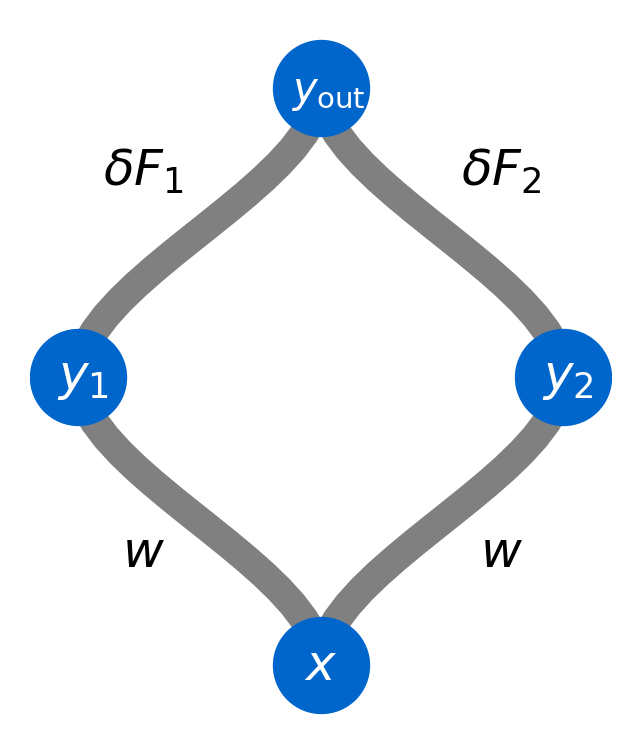

In [120]:
w = 1.
Y1 = xx_approx[1]
Y2 = xx_approx[3]
dF0 = yy_approx[0] # leftmost value, treated as bias term in final neuron
dF1 = yy_approx[2] - yy_approx[1]
dF2 = yy_approx[4] - yy_approx[3]
weights = [[[w], [w]], [[dF1, dF2]]]
biases = [[-w * Y1, -w * Y2], [dF0]]

def custom_neuron_style(bias, value, vmax):
    style = default_neuron_style(bias, value, vmax)
    style["col"] = [0., 0.4, 0.8]
    style["size"] = 500.
    return style

def custom_connection_style(weight, y, vmax):
    style = default_connection_style(weight, y, vmax)
    style["linewidth"] = 7.0
    style["col"] = "grey"
    return style

fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights,
    biases=biases,
    activations=['sigmoid', 'linear'],
    y_in = [1], 
    xspacing=0.5, yspacing=0.5, 
    figsize=(2.5, 3), 
    neuron_kwargs={"stylefunc": custom_neuron_style}, 
    connection_kwargs={"stylefunc": custom_connection_style})

# Neuron text
ax.text(posX[0][0]-0.017, posY[0][0]-0.025, r"$x$", zorder=10, color="white", size=12)
ax.text(posX[1][0]-0.022, posY[1][0]-0.024, r"$y_1$", zorder=10, color="white", size=12)
ax.text(posX[1][1]-0.022, posY[1][1]-0.024, r"$y_2$", zorder=10, color="white", size=12)
ax.text(posX[2][0]-0.031, posY[2][0]-0.024, r"$y_{\text{out}}$", zorder=10, color="white", size=10)

# Weights
ax.text((posX[0][0] + posX[1][0])/2 - 0.08, (posY[0][0] + posY[1][0])/2 - 0.08, r"$w$", zorder=10, color="black", size=12)
ax.text((posX[0][0] + posX[1][1])/2 + 0.04, (posY[0][0] + posY[1][1])/2 - 0.08, r"$w$", zorder=10, color="black", size=12)
ax.text((posX[1][0] + posX[2][0])/2 - 0.1, (posY[1][0] + posY[2][0])/2 + 0.08, r"$\delta F_1$", zorder=10, color="black", size=12)
ax.text((posX[1][1] + posX[2][0])/2 + 0.02, (posY[1][1] + posY[2][0])/2 + 0.08, r"$\delta F_2$", zorder=10, color="black", size=12)

fig.savefig("uat_build_2_nn.svg")

    

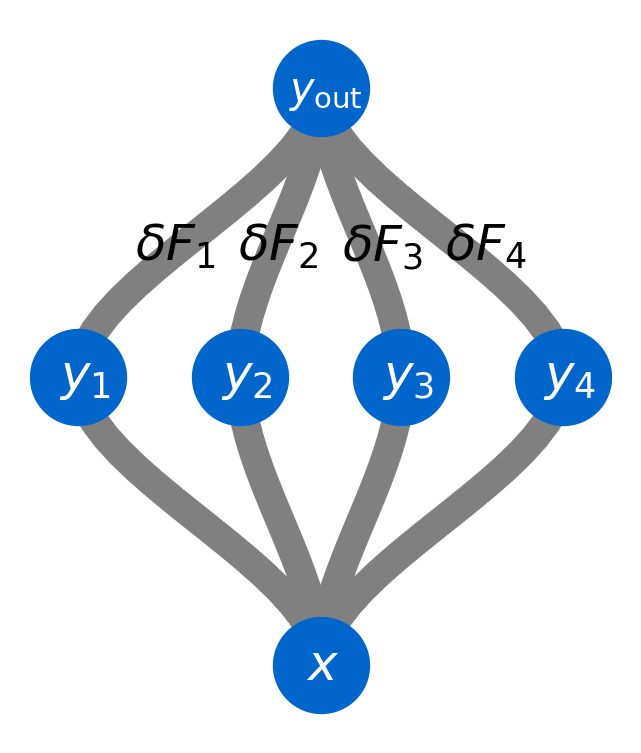

In [145]:
# Draw the neural network with 4 step functions
w = 1.
Y1 = xx_approx[1]
Y2 = xx_approx[3]
Y3 = xx_approx[5]
Y4 = xx_approx[7]
dF0 = yy_approx[0] # leftmost value, treated as bias term in final neuron
dF1 = yy_approx[2] - yy_approx[1]
dF2 = yy_approx[4] - yy_approx[3]
dF3 = yy_approx[6] - yy_approx[5]
dF4 = yy_approx[8] - yy_approx[7]
weights = [[[w], [w], [w], [w]], [[dF1, dF2, dF3, dF4]]]
biases = [[-w * Y1, -w * Y2, -w * Y3, -w * Y4], [dF0]]

def custom_neuron_style(bias, value, vmax):
    style = default_neuron_style(bias, value, vmax)
    style["col"] = [0., 0.4, 0.8]
    style["size"] = 500.
    return style

def custom_connection_style(weight, y, vmax):
    style = default_connection_style(weight, y, vmax)
    style["linewidth"] = 7.0
    style["col"] = "grey"
    return style

fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights,
    biases=biases,
    activations=['sigmoid', 'linear'],
    y_in = [1], 
    xspacing=0.5, yspacing=0.5, 
    figsize=(2.5, 3), 
    neuron_kwargs={"stylefunc": custom_neuron_style}, 
    connection_kwargs={"stylefunc": custom_connection_style})

# Neuron text
ax.text(posX[0][0]-0.045, posY[0][0]-0.025, r"$x$", zorder=10, color="white", size=12)
ax.text(posX[1][0]-0.06, posY[1][0]-0.024, r"$y_1$", zorder=10, color="white", size=12)
ax.text(posX[1][1]-0.06, posY[1][1]-0.024, r"$y_2$", zorder=10, color="white", size=12)
ax.text(posX[1][2]-0.06, posY[1][2]-0.024, r"$y_3$", zorder=10, color="white", size=12)
ax.text(posX[1][3]-0.06, posY[1][3]-0.024, r"$y_4$", zorder=10, color="white", size=12)
ax.text(posX[2][0]-0.1, posY[2][0]-0.024, r"$y_{\text{out}}$", zorder=10, color="white", size=10)

# Weights
ax.text((posX[1][0] + posX[2][0])/2-0.2, (posY[1][0] + posY[2][0])/2 - 0.05, r"$\delta F_1$", zorder=10, color="black", size=12)
ax.text((posX[1][1] + posX[2][0])/2-0.13, (posY[1][1] + posY[2][0])/2 - 0.05, r"$\delta F_2$", zorder=10, color="black", size=12)
ax.text((posX[1][2] + posX[2][0])/2-0.06, (posY[1][2] + posY[2][0])/2 - 0.05, r"$\delta F_3$", zorder=10, color="black", size=12)
ax.text((posX[1][3] + posX[2][0])/2+0.01, (posY[1][3] + posY[2][0])/2 - 0.05, r"$\delta F_4$", zorder=10, color="black", size=12)

fig.savefig("uat_build_4_nn.svg")

    

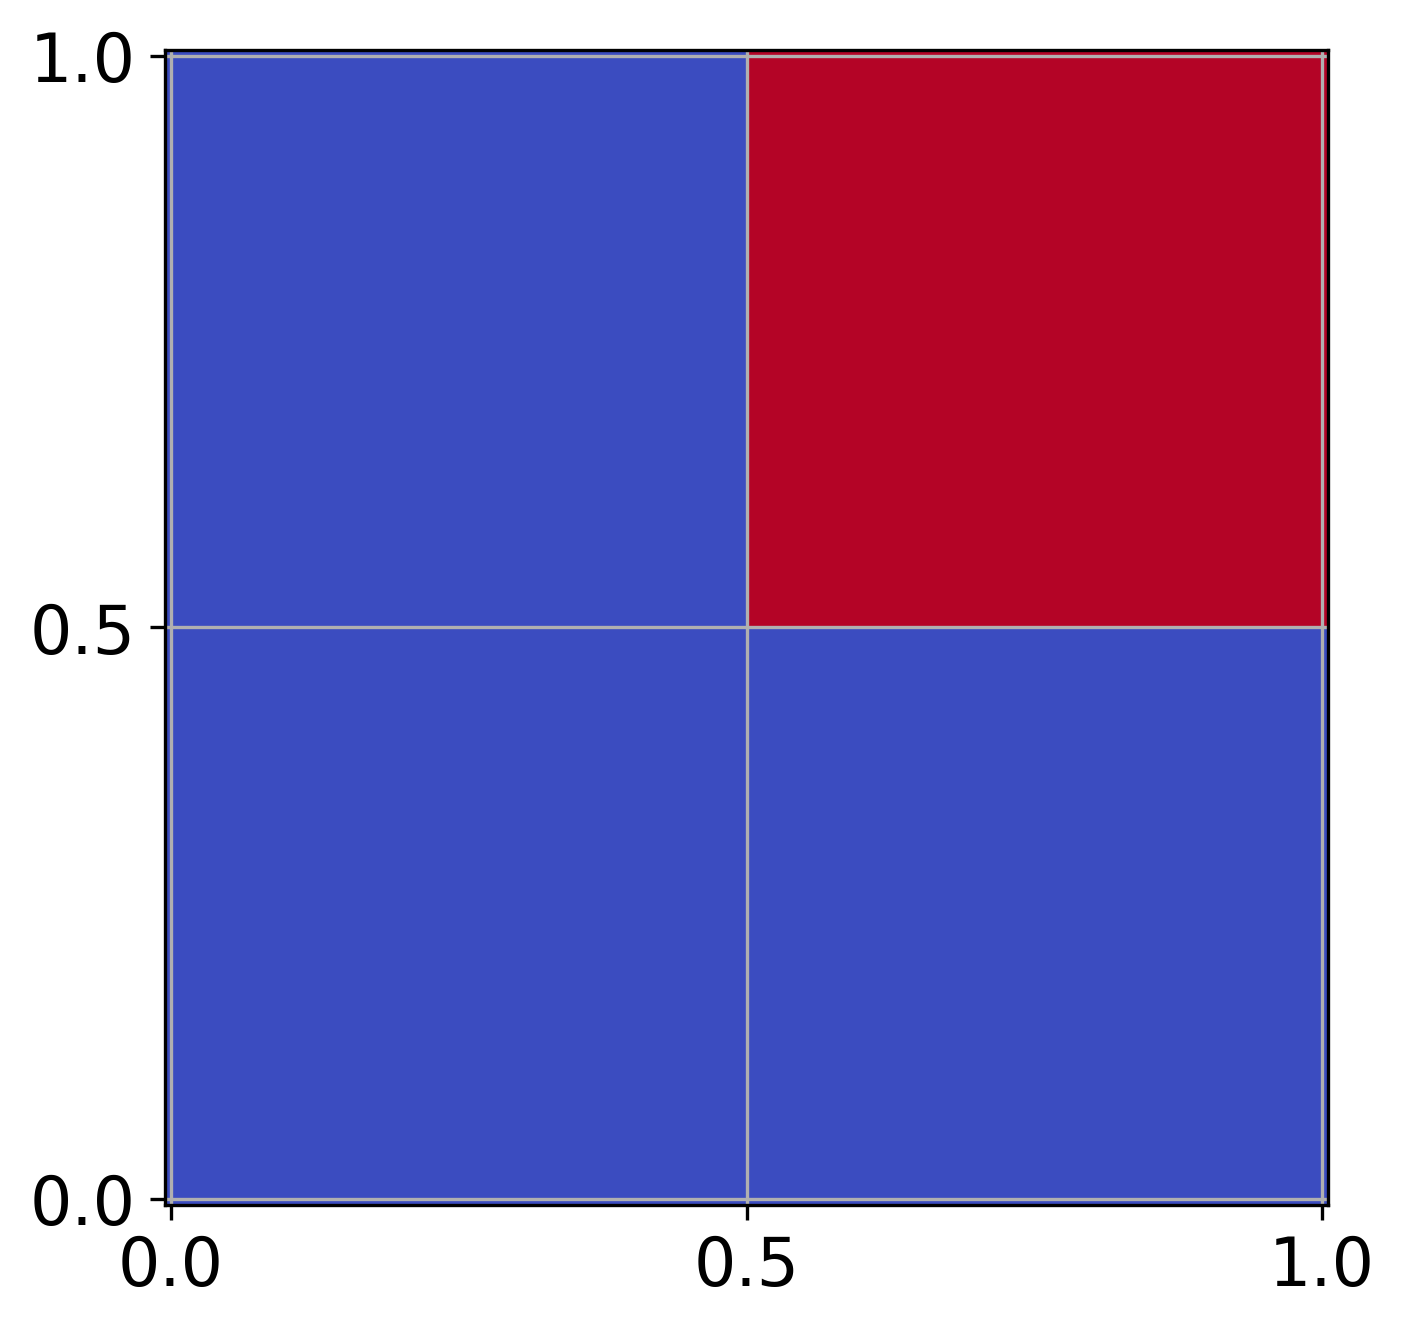

In [163]:
# 2D step function
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
xx, yy = np.meshgrid(x, y)
zz = np.where((xx > 0.5) & (yy > 0.5), 1, 0)
fig, ax = plt.subplots(figsize=(5, 5))
mesh = ax.pcolormesh(xx, yy, zz, cmap="coolwarm")
ax.set_xticks([0, 0.5, 1.0])
ax.set_yticks([0, 0.5, 1.0])
fig.savefig("uat_2dstep.svg")

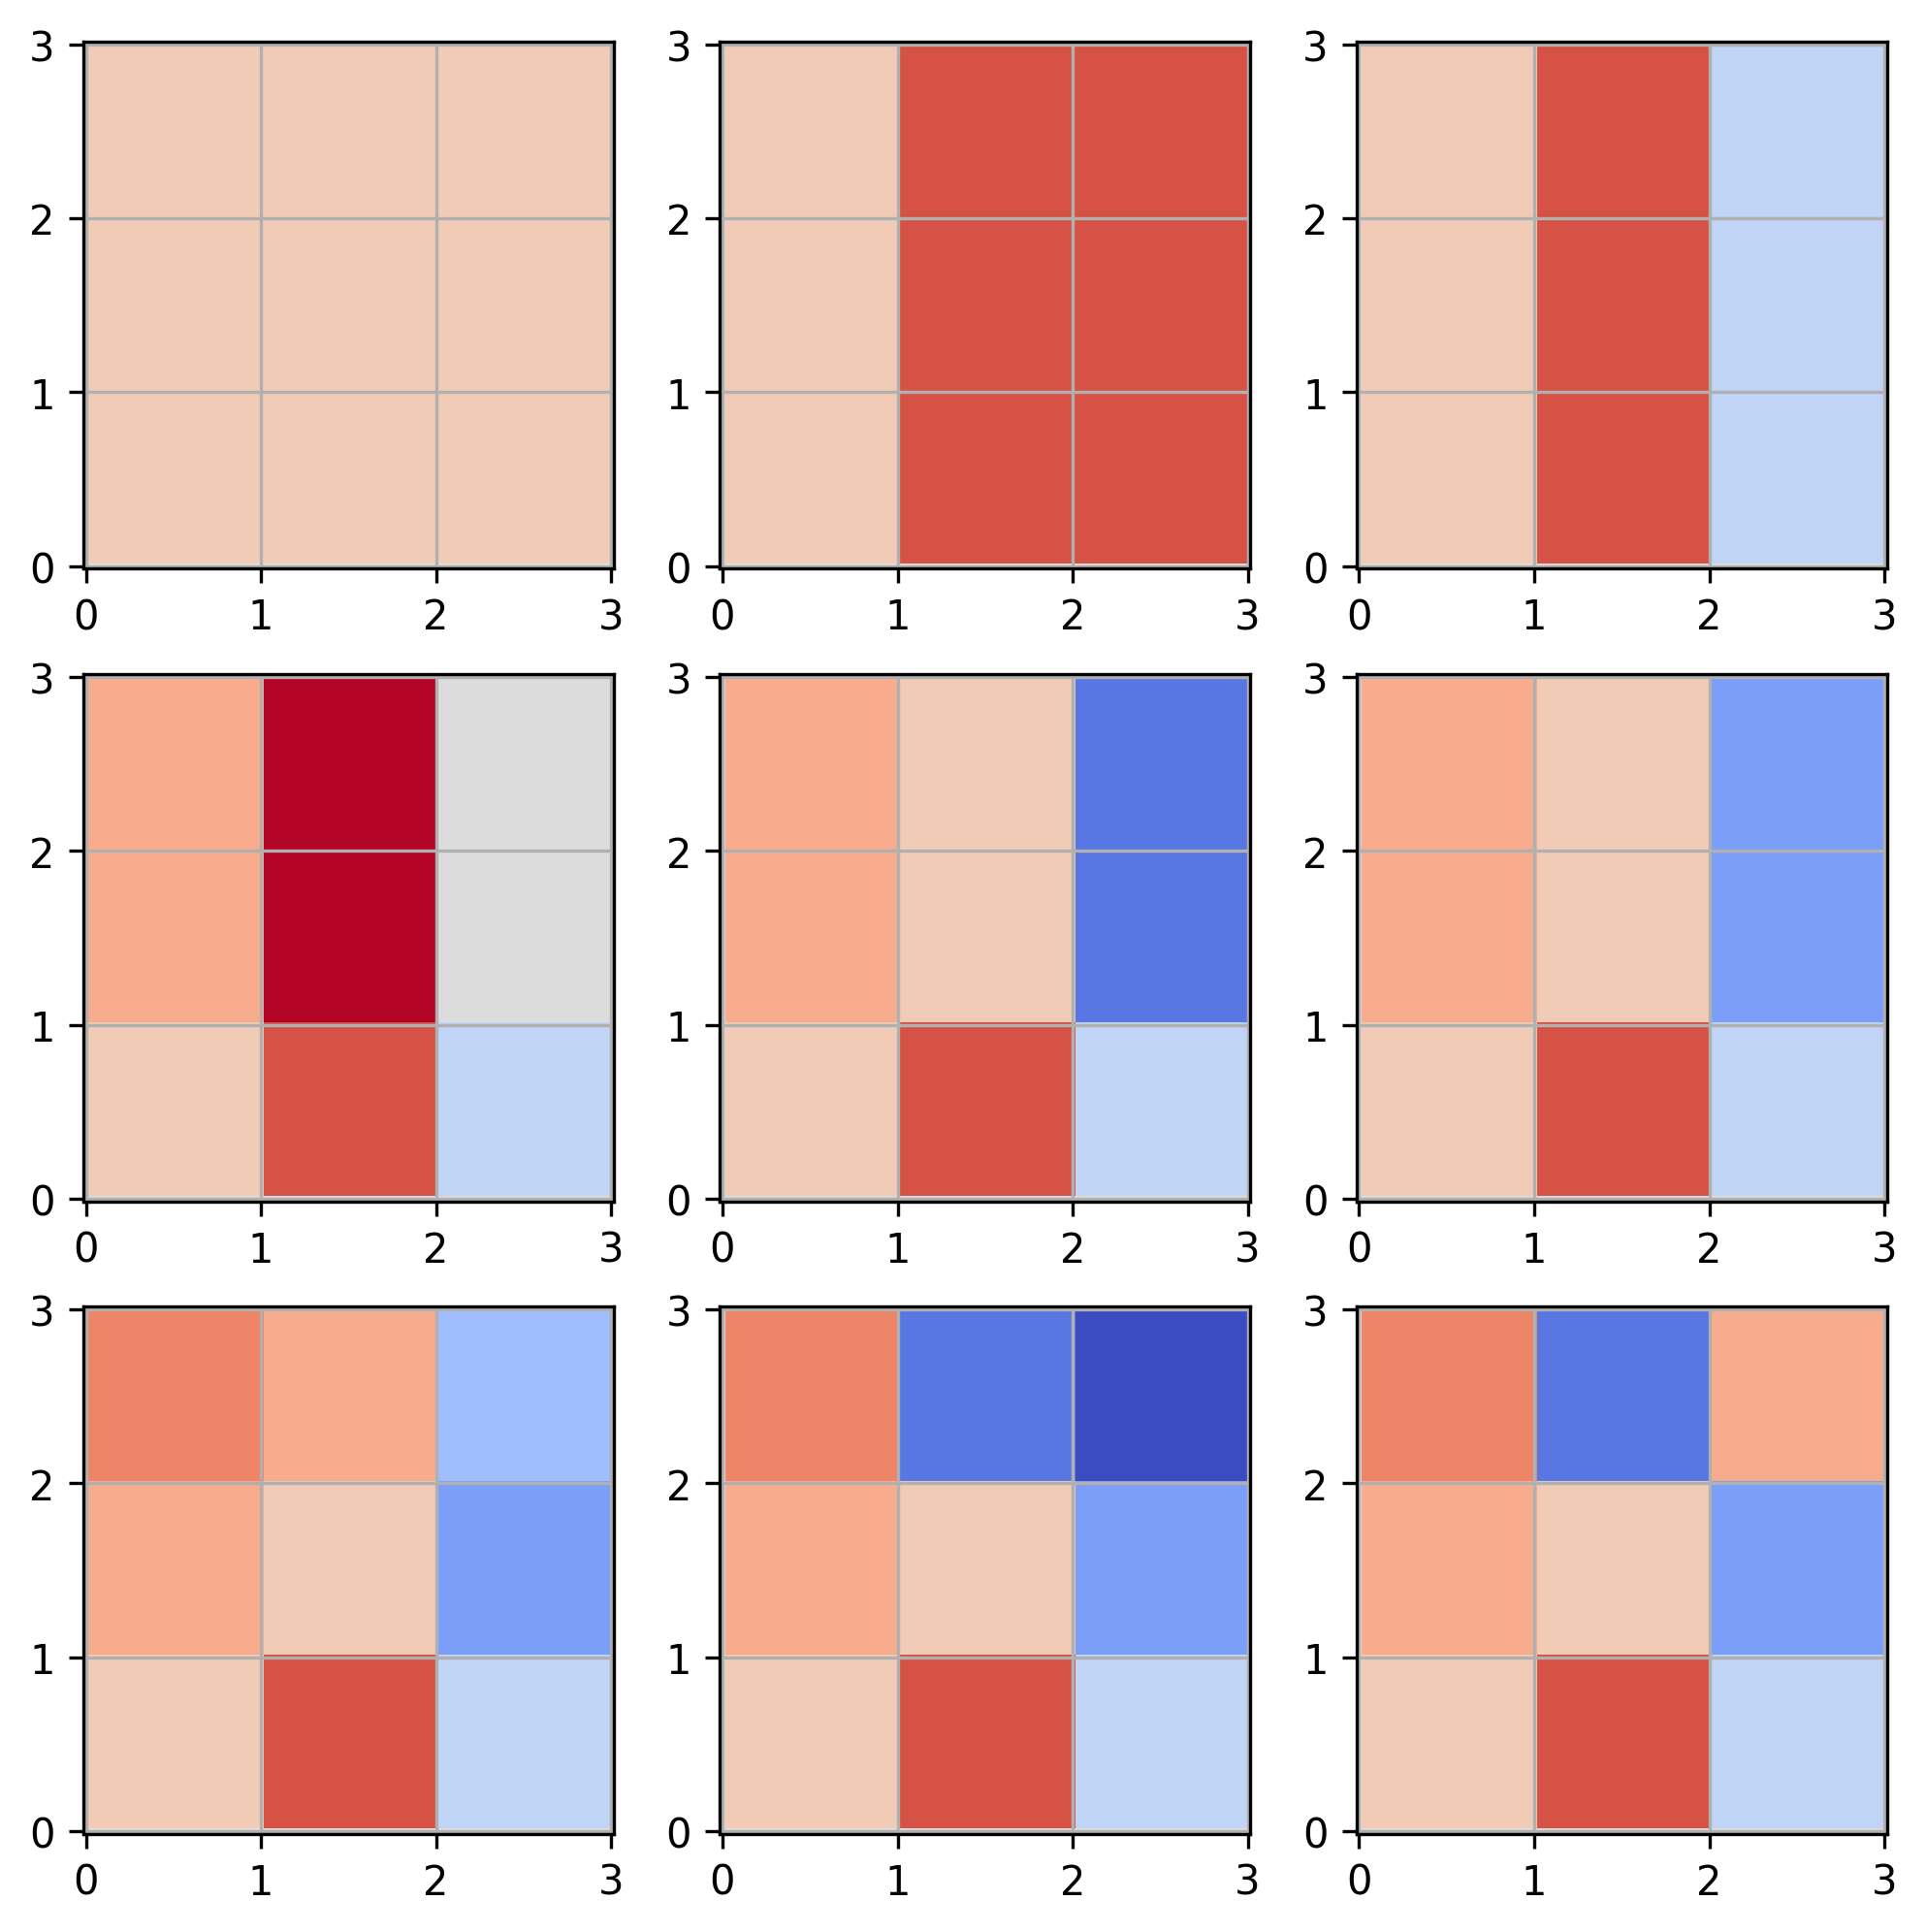

In [182]:
# Add a few step functions together
def make_step(x0, y0, h=1):
    def step(x, y):
        return ((x>x0)&(y>y0)) * h
    return step

step_funcs = []
step_funcs.append(make_step(0., 0., 1))
step_funcs.append(make_step(1., 0., 3))
step_funcs.append(make_step(2., 0., -5))
step_funcs.append(make_step(0., 1., 1))
step_funcs.append(make_step(1., 1., -4))
step_funcs.append(make_step(2., 1., 1))
step_funcs.append(make_step(0., 2., 1))
step_funcs.append(make_step(1., 2., -6))
step_funcs.append(make_step(2., 2., 10))

x = np.linspace(0., 3., 100)
y = np.linspace(0., 3., 100)
xx, yy = np.meshgrid(x, y)
zz = np.zeros_like(xx)
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
for i, step_func in enumerate(step_funcs):
    zz += step_func(xx, yy)
    axs.ravel()[i].pcolormesh(xx, yy, zz, vmin=-5, vmax=5, cmap="coolwarm")
    axs.ravel()[i].tick_params(axis="both", labelsize=10)
    axs.ravel()[i].set_xticks([0, 1., 2., 3.0])
    axs.ravel()[i].set_yticks([0, 1., 2., 3.0])
fig.savefig("uat_2d.svg")